# Bibliotecas

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

SEED = 123

# Base e tratamento

In [2]:
df = pd.read_csv('desafio_nps_fase_1.csv')

print(df.shape)
df.head()

(2500, 19)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
def classificao(nota):
    if nota >= 9:
        return 'Promotor'
    elif nota >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(classificao)

target = 'nps_categoria'
indice = ['customer_id', 'order_id']
leakage = ['repeat_purchase_30d', 'nps_score', 'csat_internal_score']

colunas_detratores = ['delivery_delay_days', 'complaints_count', 'customer_service_contacts', 'resolution_time_days']

drop_cols = indice + leakage

**Limitações na base de dados:** identificamos inconsistências reais na base:

- 1,4% dos pedidos com desconto maior que o valor do pedido
  `df['discount_value'] > df['order_value']`
- 4,84% com atraso maior que o próprio tempo total de entrega
  `df['delivery_delay_days'] > df['delivery_time_days']`
- 21,24% com reclamação registrada sem nenhum contato de atendimento.
  `(df['complaints_count'] > 0) & (df['customer_service_contacts'] == 0)`

In [ ]:
# Verificar SE tratar incosistências, ignora, ou exclui

# Modelagem

## Funções

In [23]:
# split 80 x 20 (estratificado pela variável target nps_categoria)
def preparar_dados(df, drop_cols, target, seed, colunas=None):
    """
    Seleciona as variáveis, separa X e y e realiza o split estratificado entre
    treino e teste.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base de dados original.
    drop_cols : list
        Lista de colunas que devem ser removidas das variáveis preditoras.
    target : str
        Nome da variável alvo.
    seed : int
        Semente utilizada para garantir a reprodutibilidade do split.
    colunas : list, opcional
        Lista de variáveis específicas a serem utilizadas. Se None, utiliza
        todas as variáveis disponíveis após a remoção de drop_cols e target.

    Retorno
    -------
    X_train : pandas.DataFrame
        Variáveis preditoras do conjunto de treino.
    X_test : pandas.DataFrame
        Variáveis preditoras do conjunto de teste.
    y_train : pandas.Series
        Variável alvo do conjunto de treino.
    y_test : pandas.Series
        Variável alvo do conjunto de teste.
    """
    if colunas is None:
        X = df.drop(columns=drop_cols + [target])
    else:
        X = df[colunas]

    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )

    print("Treino:")
    print(y_train.value_counts())
    print(y_train.value_counts(normalize=True))

    print("\nTeste:")
    print(y_test.value_counts().rename_axis(None))
    print(y_test.value_counts(normalize=True).rename_axis(None))

    return X_train, X_test, y_train, y_test

In [24]:
def criar_preprocessador(X_train):
    """
    Cria o pipeline de pré-processamento das variáveis preditoras.

    Variáveis numéricas são padronizadas com StandardScaler e variáveis
    categóricas são transformadas em variáveis dummy utilizando One-Hot Encoding.

    Parâmetros
    ----------
    X_train : pandas.DataFrame
        Variáveis preditoras do conjunto de treino.

    Retorno
    -------
    preprocessador : sklearn.compose.ColumnTransformer
        Objeto responsável por aplicar o pré-processamento às variáveis
        numéricas e categóricas.
    """

    num_cols = X_train.select_dtypes(include='number').columns
    cat_cols = X_train.select_dtypes(include='object').columns

    preprocessador = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    return preprocessador

In [26]:
def avaliar_modelo(modelo, X, y, nome_modelo, qtd_variaveis, cv):
    """
    Avalia um modelo utilizando validação cruzada estratificada.

    Calcula as principais métricas em cada fold, apresenta a média e o
    desvio-padrão das métricas, além do Classification Report e da
    Matriz de Confusão consolidados a partir das previsões dos folds.

    Parâmetros
    ----------
    modelo : Pipeline
        Pipeline do modelo a ser avaliado.
    X : pandas.DataFrame
        Variáveis preditoras.
    y : pandas.Series
        Variável alvo.
    nome_modelo : str
        Nome utilizado para identificar o modelo nos resultados.
    qtd_variaveis : int
        Quantidade de variáveis preditoras utilizadas pelo modelo.
    cv : estratégia de validação cruzada
        Ex.: StratifiedKFold.

    Retorno
    -------
    dict
        Dicionário contendo as médias das métricas e o desvio-padrão
        do F1 Macro.
    """

    metricas = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted'
    }

    scores = cross_validate(modelo, X, y, cv=cv, scoring=metricas)

    # Médias
    acuracia = scores['test_accuracy'].mean()
    precisao = scores['test_precision_macro'].mean()
    recall = scores['test_recall_macro'].mean()
    f1_macro = scores['test_f1_macro'].mean()
    f1_weighted = scores['test_f1_weighted'].mean()

    # Desvios-padrão
    acuracia_dp = scores['test_accuracy'].std()
    precisao_dp = scores['test_precision_macro'].std()
    recall_dp = scores['test_recall_macro'].std()
    f1_macro_dp = scores['test_f1_macro'].std()
    f1_weighted_dp = scores['test_f1_weighted'].std()

    # Exibição das métricas
    print()
    print("Acurácia:", round(acuracia, 4),
          "±", round(acuracia_dp, 4))
    # print("Precisão Macro:", round(precisao, 4),
    #       "±", round(precisao_dp, 4))
    # print("Recall Macro:", round(recall, 4),
    #       "±", round(recall_dp, 4))
    print("F1 Macro:", round(f1_macro, 4),
          "±", round(f1_macro_dp, 4))
    # print("F1 Weighted:", round(f1_weighted, 4),
    #       "±", round(f1_weighted_dp, 4))

    return {
        'Modelo': nome_modelo,
        'Qtd de variáveis': qtd_variaveis,
        'Acurácia': acuracia,
        'Precisão Macro': precisao,
        'Recall Macro': recall,
        'F1 Macro': f1_macro,
        'F1 Macro DP': f1_macro_dp,
        'F1 Weighted': f1_weighted
    }

In [27]:
def criar_preprocessador_arvores(X_train):
    """
    Cria o pré-processador para modelos baseados em árvores.

    Variáveis categóricas são transformadas utilizando One-Hot Encoding.
    Variáveis numéricas são mantidas em sua escala original, pois modelos
    baseados em árvores não necessitam de padronização.

    Parâmetros
    ----------
    X_train : pandas.DataFrame
        Conjunto de variáveis preditoras de treino.

    Retorno
    -------
    preprocessador : sklearn.compose.ColumnTransformer
        Objeto responsável pelo tratamento das variáveis categóricas e
        numéricas antes do treinamento do modelo.
    """

    cat_cols = X_train.select_dtypes(include='object').columns
    num_cols = X_train.select_dtypes(include='number').columns

    preprocessador = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    return preprocessador

In [28]:
def buscar_melhor_rf(X_train, y_train, preprocessador, param_grid, seed):
    """
    Realiza busca exaustiva de hiperparâmetros para um Random Forest
    utilizando validação cruzada estratificada.

    Parâmetros
    ----------
    X_train : pandas.DataFrame
        Variáveis preditoras do conjunto de treino.
    y_train : pandas.Series
        Variável alvo do conjunto de treino.
    preprocessador : sklearn.compose.ColumnTransformer
        Pré-processador utilizado antes do Random Forest.
    param_grid : dict
        Dicionário contendo as combinações de hiperparâmetros a serem testadas.
    seed : int
        Semente utilizada para garantir reprodutibilidade.

    Retorno
    -------
    grid_search : sklearn.model_selection.GridSearchCV
        Objeto contendo os resultados da busca e o melhor modelo encontrado.
    """

    modelo = Pipeline([
        ('preprocessamento', preprocessador),
        ('modelo', RandomForestClassifier(random_state=seed))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    grid_search = GridSearchCV(
        estimator=modelo,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train)

    return grid_search

## 1. Regressão Logística

### Simples

In [30]:
X_train, X_test, y_train, y_test = preparar_dados(df, drop_cols, target, SEED)

preprocessador = criar_preprocessador(X_train)

modelo_logistico = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo(
        modelo_logistico,
        X_train,
        y_train,
        nome_modelo='Regressão Logística - CV',
        qtd_variaveis=X_train.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.8465 ± 0.0046
F1 Macro: 0.457 ± 0.0169


### Balanceada

In [31]:
X_train, X_test, y_train, y_test = preparar_dados(df, drop_cols, target, SEED)

preprocessador = criar_preprocessador(X_train)

modelo_logistico_balanceado = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression(class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo(
        modelo_logistico_balanceado,
        X_train,
        y_train,
        nome_modelo='Regressão Logística Balanceada - CV',
        qtd_variaveis=X_train.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.733 ± 0.0111
F1 Macro: 0.4986 ± 0.0052


### Simples + Parcimônia

In [32]:
X_train_4, X_test_4, y_train_4, y_test_4 = preparar_dados(df, drop_cols, target, SEED, colunas=colunas_detratores)

preprocessador = criar_preprocessador(X_train_4)

modelo_logistico_4 = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo(
        modelo_logistico_4,
        X_train_4,
        y_train_4,
        nome_modelo='Regressão Logística - CV',
        qtd_variaveis=X_train_4.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.847 ± 0.0075
F1 Macro: 0.4393 ± 0.0318


### Balanceada + Parcimônia

In [33]:
X_train_4, X_test_4, y_train_4, y_test_4 = preparar_dados(df, drop_cols, target, SEED, colunas=colunas_detratores)

preprocessador = criar_preprocessador(X_train_4)

modelo_logistico_balanceado_4 = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression(class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo(
        modelo_logistico_balanceado_4,
        X_train_4,
        y_train_4,
        nome_modelo='Regressão Logística Balanceada - CV',
        qtd_variaveis=X_train_4.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.733 ± 0.0037
F1 Macro: 0.5142 ± 0.013


## 2. Random Forest

### Grid - Todas as variáveis
Grid para investigar a melhor combinação no Random Forest

In [ ]:
# RODAR APENAS PARA TESTAR O MELHOR PARÂMETRO

# Parâmetros encontrados pelo GridSearchCV
# Foram testadas:
# param_grid = {
#     'modelo__n_estimators': [100, 300],
#     'modelo__max_depth': [5, 10, None],
#     'modelo__min_samples_leaf': [1, 5, 10],
#     'modelo__class_weight': [None, 'balanced']
# }

# X_train, X_test, y_train, y_test = preparar_dados(
#     df,
#     drop_cols,
#     target,
#     SEED
# )

# preprocessador = criar_preprocessador_arvores(X_train)

# grid_rf_todas = buscar_melhor_rf(
#     X_train,
#     y_train,
#     preprocessador,
#     param_grid,
#     SEED
# )

# print()
# print("Melhor F1 Macro:", grid_rf_todas.best_score_)
# print("Melhores parâmetros:")
# print(grid_rf_todas.best_params_)

In [34]:
# RODAR APENAS QUANDO TIVER OS MELHORES PARÂMTEROS

# Melhores parâmetros:
parametros_rf = {
    'n_estimators': 300,
    'max_depth': 5,
    'min_samples_leaf': 5,
    'class_weight': 'balanced'
}

X_train, X_test, y_train, y_test = preparar_dados(df, drop_cols, target, SEED)

preprocessador = criar_preprocessador_arvores(X_train)

modelo_rf_grid = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', RandomForestClassifier(random_state=SEED, **parametros_rf))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo(
        modelo_rf_grid,
        X_train,
        y_train,
        nome_modelo='Random Forest - Balanceado - CV',
        qtd_variaveis=X_train.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.77 ± 0.0089
F1 Macro: 0.516 ± 0.0106


### Grid - Parcimônia

In [ ]:
# RODAR APENAS PARA TESTAR O MELHOR PARÂMETRO

# X_train_4, X_test_4, y_train_4, y_test_4 = preparar_dados(
#     df,
#     drop_cols,
#     target,
#     SEED,
#     colunas=colunas_detratores
# )

# preprocessador_4 = criar_preprocessador_arvores(X_train_4)

# grid_rf_4 = buscar_melhor_rf(
#     X_train_4,
#     y_train_4,
#     preprocessador_4,
#     param_grid,
#     SEED
# )

# print()
# print("Melhor F1 Macro:", grid_rf_4.best_score_)
# print("Melhores parâmetros:")
# print(grid_rf_4.best_params_)

In [35]:
# RODAR APENAS QUANDO TIVER OS MELHORES PARÂMTEROS

# Melhores parâmetros:
parametros_rf = {
    'n_estimators': 300,
    'max_depth': 5,
    'min_samples_leaf': 5,
    'class_weight': 'balanced'
}

X_train_4, X_test_4, y_train_4, y_test_4 = preparar_dados(df, drop_cols, target, SEED, colunas=colunas_detratores)

preprocessador = criar_preprocessador_arvores(X_train_4)

modelo_rf_grid_4 = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', RandomForestClassifier(random_state=SEED, **parametros_rf))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo(
        modelo_rf_grid_4,
        X_train_4,
        y_train_4,
        nome_modelo='Random Forest - Balanceado - CV',
        qtd_variaveis=X_train_4.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.727 ± 0.007
F1 Macro: 0.4986 ± 0.006


## 3. XGBoost

In [36]:
X_train, X_test, y_train, y_test = preparar_dados(df, drop_cols, target, SEED)

preprocessador = criar_preprocessador_arvores(X_train)

# Codificar a target para 0, 1 e 2
encoder = LabelEncoder()
y_train_xgb = encoder.fit_transform(y_train)

modelo_xgb = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', XGBClassifier(random_state=SEED))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo_cv(
        modelo_xgb,
        X_train,
        y_train_xgb,
        nome_modelo='XGBoost - CV',
        qtd_variaveis=X_train.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.8335 ± 0.0101
F1 Macro: 0.4238 ± 0.0483


In [47]:
X_train_4, X_test_4, y_train_4, y_test_4 = preparar_dados(df, drop_cols, target, SEED, colunas=colunas_detratores)

preprocessador = criar_preprocessador_arvores(X_train_4)

# Codificar a target para 0, 1 e 2
encoder = LabelEncoder()
y_train_xgb_4 = encoder.fit_transform(y_train_4)

modelo_xgb = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', XGBClassifier(random_state=SEED))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados.append(
    avaliar_modelo_cv(
        modelo_xgb,
        X_train_4,
        y_train_xgb_4,
        nome_modelo='XGBoost - CV',
        qtd_variaveis=X_train_4.shape[1],
        cv=cv
    )
)

Treino:
nps_categoria
Detrator    1687
Neutro       225
Promotor      88
Name: count, dtype: int64
nps_categoria
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: proportion, dtype: float64

Teste:
Detrator    422
Neutro       56
Promotor     22
Name: count, dtype: int64
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: proportion, dtype: float64

Acurácia: 0.818 ± 0.0153
F1 Macro: 0.4536 ± 0.0361


## Compilado dos Resultados

In [48]:
df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by='F1 Macro', ascending=False) # F1 Weighted

,Modelo,Qtd de variáveis,Acurácia,Precisão Macro,Recall Macro,F1 Macro,F1 Macro DP,F1 Weighted
4,Random Forest - Grid - CV,14,0.7700,0.494240,0.567739,0.515994,0.010642,0.797992
3,Regressão Logística Balanceada - CV,4,0.7330,0.487451,0.633651,0.514215,0.013025,0.776250
5,Random Forest - Grid - CV,4,0.7270,0.476740,0.595561,0.498605,0.006011,0.771559
1,Regressão Logística Balanceada - CV,14,0.7330,0.477317,0.607267,0.498554,0.005172,0.776665
0,Regressão Logística - CV,14,0.8465,0.544355,0.431478,0.457047,0.016856,0.816158
7,XGBoost - CV,4,0.8180,0.480213,0.441448,0.453645,0.036088,0.805493
2,Regressão Logística - CV,4,0.8470,0.606753,0.415711,0.439307,0.031780,0.813654
6,XGBoost - CV,14,0.8335,0.492391,0.406309,0.423842,0.048264,0.804724


Foi desenvolvido um modelo de classificação para prever a **categoria de NPS** — `Detrator`, `Neutro` ou `Promotor`. A variável nps_score foi transformada em uma variável categórica, foram removidos identificadores e possíveis variáveis de leakage, e os dados foram preparados com separação estratificada. A EDA identificou 4 variáveis com evidências de associação com as categorias de NPS, permitindo também avaliar uma abordagem mais parcimoniosa.

Foram testados:

- Regressão Logística;
- Regressão Logística balanceada;
- Random Forest, otimizado por _GridSearch_;
- XGBoost

Após observar variação relevante nos resultados conforme o seed, a avaliação passou a utilizar validação cruzada estratificada com 5 folds, reduzindo a dependência de uma única divisão treino/teste.

<!--
> **Escolha sugerida**

A melhor alternativa atualmente é a Regressão Logística Balanceada com 4 variáveis, que apresentou o maior F1 Macro (0,509) e também o maior Recall Macro (0,626).

A escolha é favorecida por três fatores:

1. Melhor desempenho geral entre os modelos avaliados;
2. Apenas 4 variáveis, mantendo a solução simples e parcimoniosa;
3. O balanceamento melhora a capacidade de identificar as classes minoritárias.

Como a prioridade de negócio definida é identificar corretamente os Detratores, o próximo passo deve ser verificar especificamente o Recall e o F1 da classe Detrator, além da matriz de confusão.-->

## Avaliando 2 melhores modelos

In [46]:
candidatos = {
    'RF - Grid - 14 var': modelo_rf_grid,
    'LogReg Balanceada - 4 var': modelo_logistico_balanceado_4,
    # 'LogReg - 14 var': modelo_logistico
}

for nome, modelo in candidatos.items():
    y_pred_cv = cross_val_predict(modelo, X_train, y_train, cv=cv)
    print(f"------- {nome} -------")
    print(classification_report(y_train, y_pred_cv))
    print()
    print(confusion_matrix(y_train, y_pred_cv))
    print()

------- RF - Grid - 14 var -------
              precision    recall  f1-score   support

    Detrator       0.96      0.77      0.86      1687
      Neutro       0.23      0.44      0.30       225
    Promotor       0.24      0.57      0.34        88

    accuracy                           0.73      2000
   macro avg       0.48      0.60      0.50      2000
weighted avg       0.85      0.73      0.77      2000


[[1304  301   82]
 [  47  100   78]
 [   6   32   50]]

------- LogReg Balanceada - 4 var -------
              precision    recall  f1-score   support

    Detrator       0.97      0.77      0.86      1687
      Neutro       0.24      0.44      0.31       225
    Promotor       0.26      0.68      0.37        88

    accuracy                           0.73      2000
   macro avg       0.49      0.63      0.51      2000
weighted avg       0.85      0.73      0.78      2000


[[1306  291   90]
 [  40  100   85]
 [   7   21   60]]



## Modelo Campeão

Selecionando os dois melhores modelos de acordo com o F1 Macro, observa-se que seus desempenhos são bastante semelhantes. Diante disso, sugere-se a **Regressão Logística Balanceada com apenas 4 variáveis** como a melhor alternativa, seguindo o princípio da parcimônia, uma vez que apresenta desempenho competitivo com uma solução mais simples, com menor número de variáveis e maior interpretabilidade.

### Avaliação do Teste

O modelo captura 76% dos detratores reais com alta confiabilidade (precisão de 97% — quando aponta detrator, quase sempre acerta). Neutro e Promotor têm recall razoável (45% e 59%), mas precisão baixa (25% e 20%), refletindo o desbalanceamento severo da base (apenas 56 neutros e 22 promotores no teste, contra 422 detratores). Acurácia geral de 72%, com F1 Macro de 0,49 — a métrica mais baixa que a acurácia confirma que o modelo tem mais dificuldade nas classes minoritárias do que a acurácia sozinha sugeriria.

In [50]:
preprocessador_4 = criar_preprocessador(X_train_4)

modelo_final = Pipeline([
    ('preprocessamento', preprocessador_4),
    ('modelo', LogisticRegression(class_weight='balanced', random_state=SEED))
])

modelo_final.fit(X_train_4, y_train_4)
y_pred_final = modelo_final.predict(X_test_4)

print(classification_report(y_test_4, y_pred_final))

print(confusion_matrix(y_test_4, y_pred_final))

              precision    recall  f1-score   support

    Detrator       0.97      0.76      0.85       422
      Neutro       0.25      0.45      0.32        56
    Promotor       0.20      0.59      0.30        22

    accuracy                           0.72       500
   macro avg       0.47      0.60      0.49       500
weighted avg       0.85      0.72      0.77       500

[[321  71  30]
 [  8  25  23]
 [  3   6  13]]


### Análise de erro

Os erros de classificação (Detator ⟷ Promotor) se concentram na região de baixo delivery_delay_days (0–3 dias) combinada com valores intermediários de complaints_count e resolution_time_days.

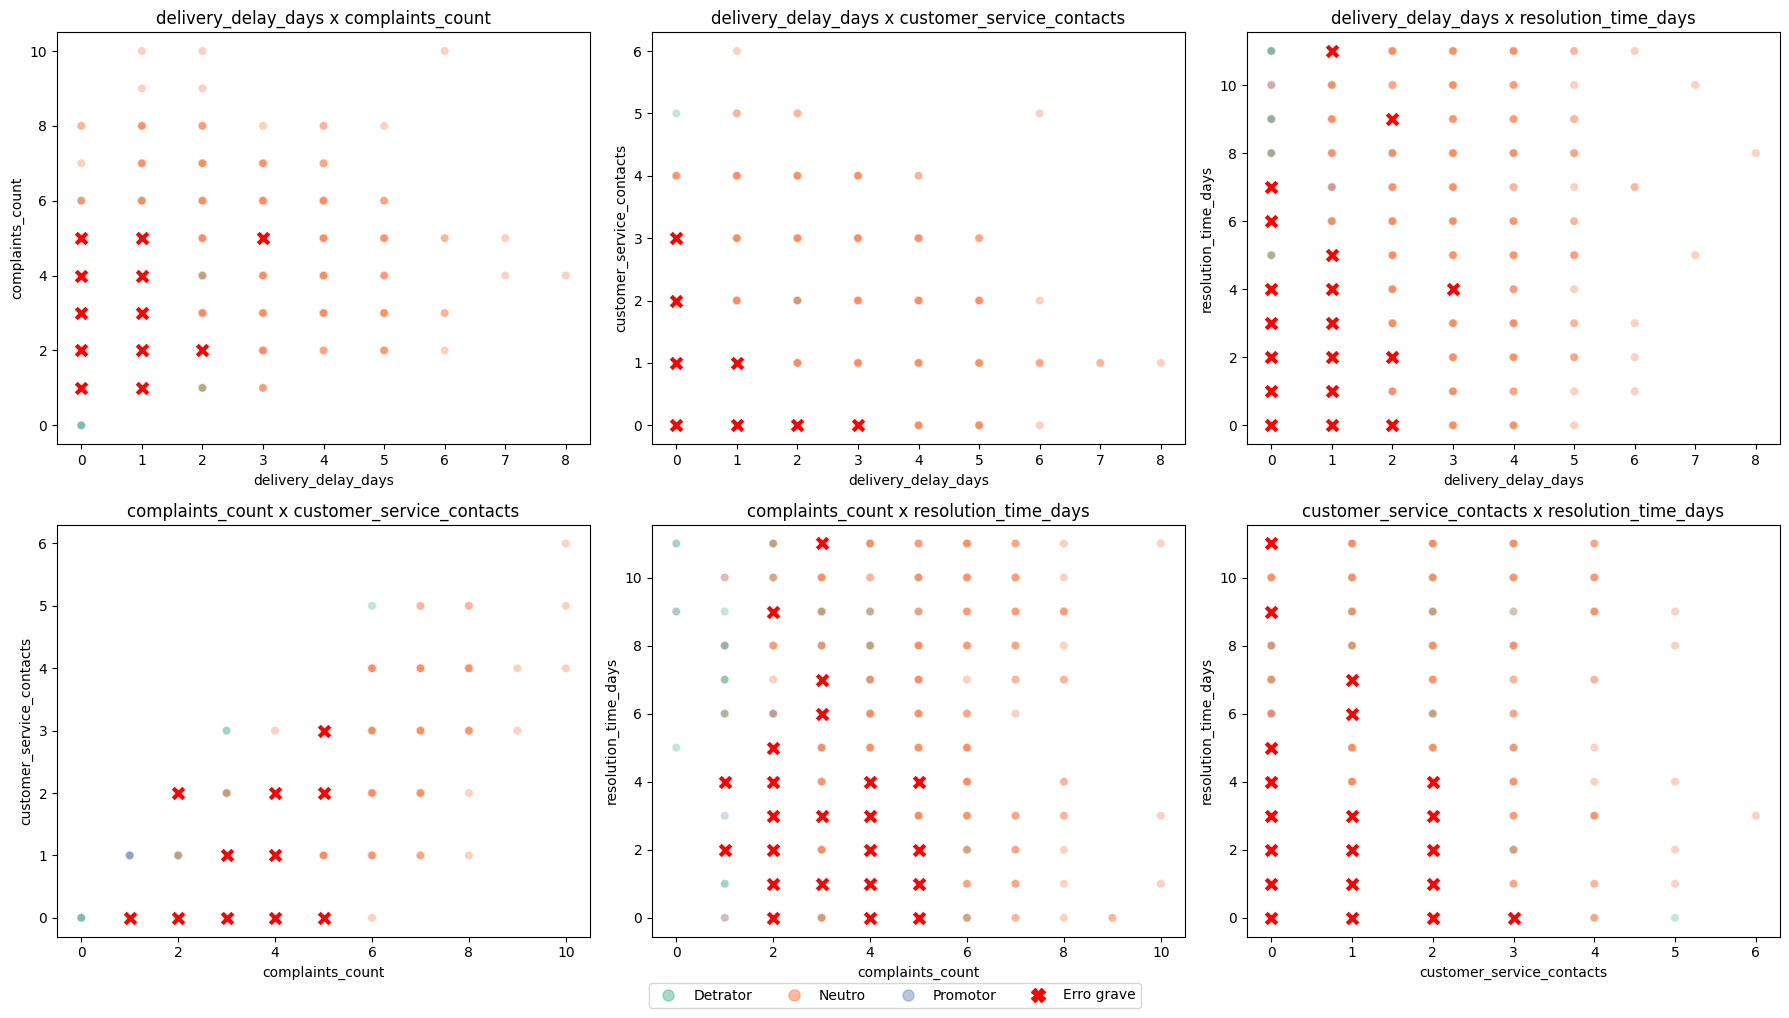

In [67]:
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

pares = list(combinations(X_train_4.columns, 2))
n_pares = len(pares)

n_cols = 3
n_rows = -(-n_pares // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

palette = sns.color_palette('Set2', n_colors=X_test_4_erros['y_real'].nunique())
classes = sorted(X_test_4_erros['y_real'].unique())

for ax, (col1, col2) in zip(axes, pares):
    sns.scatterplot(data=X_test_4_erros, x=col1, y=col2, hue='y_real',
                      palette=palette, alpha=0.4, legend=False, ax=ax)
    sns.scatterplot(data=erros_graves, x=col1, y=col2, color='red', marker='X',
                      s=120, legend=False, ax=ax)
    ax.set_title(f'{col1} x {col2}')

# esconde eixos sobrando, se o grid tiver mais espaços que pares
for ax in axes[n_pares:]:
    ax.axis('off')

# monta a legenda manualmente: uma entrada por classe + uma pro erro grave
handles = [
    mlines.Line2D([], [], marker='o', linestyle='', color=cor, alpha=0.6, markersize=8, label=classe)
    for classe, cor in zip(classes, palette)
]
handles.append(
    mlines.Line2D([], [], marker='X', linestyle='', color='red', markersize=10, label='Erro grave')
)

fig.legend(handles=handles, loc='lower center', ncol=len(handles), bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

### Análise de variáveis

`delivery_delay_days` é o driver dominante (coeficiente 1,30 para Detrator, -1,07 para Promotor), seguido por `complaints_count` (0,81). As 4 variáveis têm direção consistente com a intuição de negócio (sempre positivas para Detrator, negativas para Promotor). `customer_service_contacts` é a mais fraca das 4, discriminando pouco entre Detrator e Neutro.

In [52]:
nomes_colunas = modelo_final.named_steps['preprocessamento'].get_feature_names_out()
coeficientes = modelo_final.named_steps['modelo'].coef_
classes = modelo_final.named_steps['modelo'].classes_

df_coef = pd.DataFrame(coeficientes.T, index=nomes_colunas, columns=classes)
df_coef.style.background_gradient(cmap='RdBu_r', axis=None)

,Detrator,Neutro,Promotor
num__delivery_delay_days,1.297687,-0.230558,-1.067128
num__complaints_count,0.805812,-0.375992,-0.429820
num__customer_service_contacts,0.196465,0.175540,-0.372005
num__resolution_time_days,0.595629,-0.052618,-0.543011


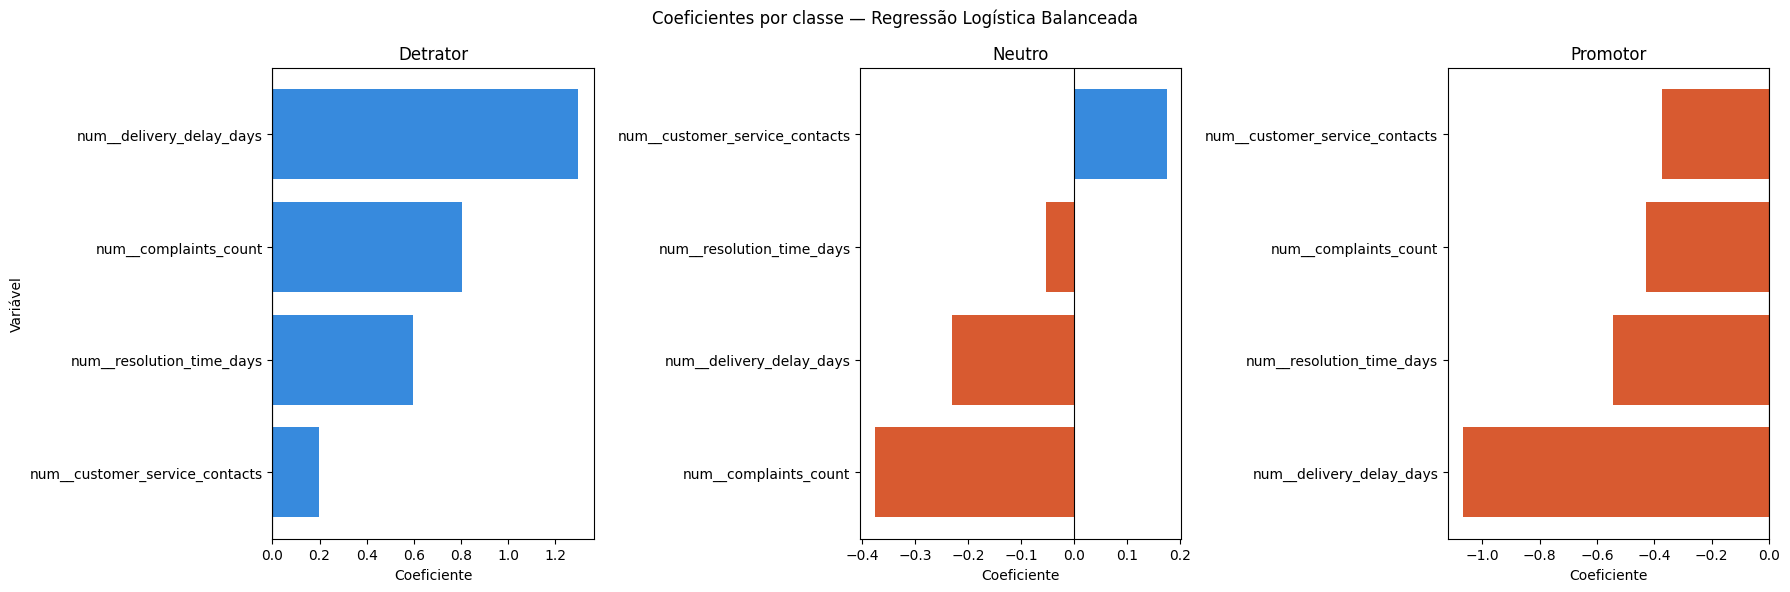

In [69]:
# outra visão

fig, axes = plt.subplots(1, len(df_coef.columns), figsize=(6 * len(df_coef.columns), 6), sharey=False)

for ax, classe in zip(axes, df_coef.columns):
    dados_ordenados = df_coef[classe].sort_values()
    cores = ['#D85A30' if v < 0 else '#378ADD' for v in dados_ordenados]

    ax.barh(dados_ordenados.index, dados_ordenados.values, color=cores)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(classe)
    ax.set_xlabel('Coeficiente')

axes[0].set_ylabel('Variável')
fig.suptitle('Coeficientes por classe — Regressão Logística Balanceada')
plt.tight_layout()
plt.show()

### Curva ROC multiclasse

AUC de 0,90 (Detrator), 0,88 (Promotor) e 0,83 (Neutro) — boa capacidade de discriminação em todas as classes, mesmo com o recall mais modesto no limiar padrão. Isso mostrou que o modelo "sabe separar" bem as classes probabilisticamente, mas o limiar de 0,5 não era o ideal para maximizar recall de detrator.

Baixando o limiar de decisão do Detrator (0,148), o recall sobe de 76% para 90% (captura quase todos os detratores) e a acurácia geral sobe para 81% — mas às custas do recall de Neutro, que cai de 45% para 21% (mais neutros passam a ser confundidos com detrator). É um trade-off de negócio: vale a pena se o custo de "perder" um detrator for maior que o custo de alarmes falsos.

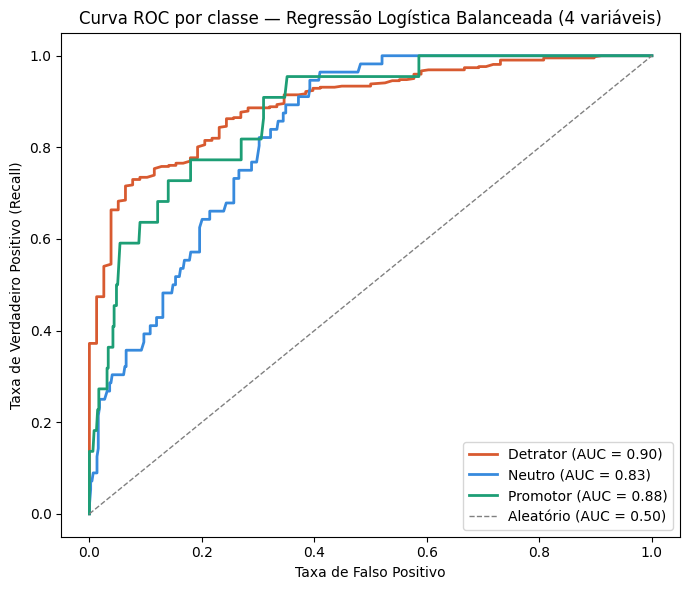

In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = ['Detrator', 'Neutro', 'Promotor']  # ajuste pra ordem/nomes exatos da sua target

y_test_bin = label_binarize(y_test_4, classes=classes)
y_score = modelo_final.predict_proba(X_test_4)

fig, ax = plt.subplots(figsize=(7, 6))

cores = ['#D85A30', '#378ADD', '#1D9E75']  # coral, azul, verde

for i, (classe, cor) in enumerate(zip(classes, cores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=cor, lw=2, label=f'{classe} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aleatório (AUC = 0.50)')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo (Recall)')
ax.set_title('Curva ROC por classe — Regressão Logística Balanceada (4 variáveis)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [68]:
idx_detrator = classes.index('Detrator')
fpr, tpr, thresholds = roc_curve(y_test_bin[:, idx_detrator], y_score[:, idx_detrator])

# achar o limiar que dá recall de pelo menos 90% pro detrator
alvo_recall = 0.90
i = next(i for i, t in enumerate(tpr) if t >= alvo_recall)
print(f"Limiar sugerido: {thresholds[i]:.3f} (TPR={tpr[i]:.2f}, FPR={fpr[i]:.2f})")

Limiar sugerido: 0.148 (TPR=0.90, FPR=0.35)


In [71]:
y_proba = modelo_final.predict_proba(X_test_4)
idx_detrator = list(modelo_final.classes_).index('Detrator')

y_pred_novo_limiar = np.where(
    y_proba[:, idx_detrator] >= 0.148,
    'Detrator',
    modelo_final.predict(X_test_4)  # mantém a previsão original pras outras classes
)

print("--- Limiar padrão (0.5) ---")
print(classification_report(y_test_4, y_pred_final))
print(confusion_matrix(y_test_4, y_pred_final))

print("--- Limiar ajustado (0.148) ---")
print(classification_report(y_test_4, y_pred_novo_limiar))
print(confusion_matrix(y_test_4, y_pred_novo_limiar))

--- Limiar padrão (0.5) ---
              precision    recall  f1-score   support

    Detrator       0.97      0.76      0.85       422
      Neutro       0.25      0.45      0.32        56
    Promotor       0.20      0.59      0.30        22

    accuracy                           0.72       500
   macro avg       0.47      0.60      0.49       500
weighted avg       0.85      0.72      0.77       500

[[321  71  30]
 [  8  25  23]
 [  3   6  13]]
--- Limiar ajustado (0.148) ---
              precision    recall  f1-score   support

    Detrator       0.93      0.90      0.92       422
      Neutro       0.40      0.21      0.28        56
    Promotor       0.20      0.59      0.30        22

    accuracy                           0.81       500
   macro avg       0.51      0.57      0.50       500
weighted avg       0.84      0.81      0.82       500

[[379  15  28]
 [ 21  12  23]
 [  6   3  13]]
